In [2]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [3]:
# 1. Load the dataset
df = pd.read_csv("Student_Performance.csv")
print(df.head())  # to preview the first few rows

   Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0              7               99                        Yes            9   
1              4               82                         No            4   
2              8               51                        Yes            7   
3              5               52                        Yes            5   
4              7               75                         No            8   

   Sample Question Papers Practiced  Performance Index  
0                                 1               91.0  
1                                 2               65.0  
2                                 2               45.0  
3                                 2               36.0  
4                                 5               66.0  


In [5]:

# 2. Encode categorical variable (Extracurricular Activities)
# If it’s 'Yes' or 'No', LabelEncoder is enough
le = LabelEncoder()
df['Extracurricular Activities'] = le.fit_transform(df['Extracurricular Activities'])
print(df.head())  # to preview the first few rows

   Hours Studied  Previous Scores  Extracurricular Activities  Sleep Hours  \
0              7               99                           1            9   
1              4               82                           0            4   
2              8               51                           1            7   
3              5               52                           1            5   
4              7               75                           0            8   

   Sample Question Papers Practiced  Performance Index  
0                                 1               91.0  
1                                 2               65.0  
2                                 2               45.0  
3                                 2               36.0  
4                                 5               66.0  


In [8]:
# 3. Define features (X) and target (y)
X = df[['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced']]
y = df['Performance Index']


In [9]:
# 4. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# 5. Train the model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [11]:
# 6. Make predictions
y_pred = model.predict(X_test)

In [12]:
# 7. Evaluate model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print("📈 Multiple Linear Regression Results")
print("-----------------------------------")
print(f"Intercept (a): {model.intercept_:.2f}")
print(f"Coefficients (b):")
for name, coef in zip(X.columns, model.coef_):
    print(f"  {name}: {coef:.2f}")
print(f"\nMean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")

📈 Multiple Linear Regression Results
-----------------------------------
Intercept (a): -33.92
Coefficients (b):
  Hours Studied: 2.85
  Previous Scores: 1.02
  Extracurricular Activities: 0.61
  Sleep Hours: 0.48
  Sample Question Papers Practiced: 0.19

Mean Squared Error: 4.08
R² Score: 0.99


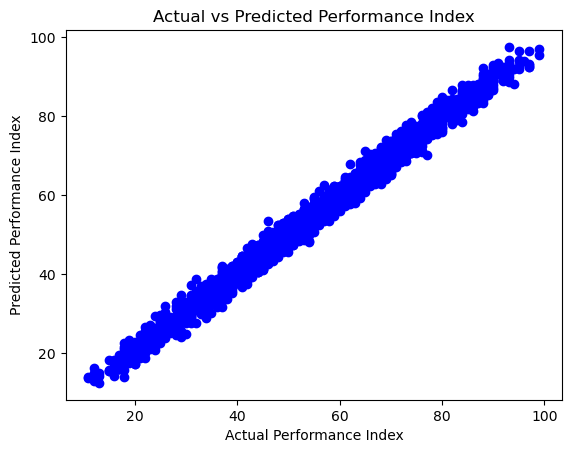

In [ ]:
# 8. (Optional) Compare actual vs predicted
plt.scatter(X_test,y  color='blue')
plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("Actual vs Predicted Performance Index")
plt.show()